<a href="https://colab.research.google.com/github/jeffmcm1977/CMBAnalysis_SummerSchool/blob/master/CMB_School_Part_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical tools for image analysis

### Renée Hložek 

This notebook series is based on tools used to analyse the Cosmic Microwave Background (CMB), which is the oldest observable light in the universe. 

## Preparing the images/maps for analysis
We make the maps and read in images from before (see Part 1 in this series). 

In [227]:
import numpy as np
import matplotlib
import sys
import matplotlib.cm as cm
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import constants as cs # the constants module
import cmb_modules # the module of functions

N = cs.N
c_min = cs.c_min
c_max = cs.c_max
X_width =cs.X_width
Y_width = cs.Y_width
beam_size_fwhp = cs.beam_size_fwhp

pix_size = cs.pix_size

Number_of_Sources  = cs.Number_of_Sources
Amplitude_of_Sources = cs.Amplitude_of_Sources
Number_of_Sources_EX = cs.Number_of_Sources_EX
Amplitude_of_Sources_EX = cs.Amplitude_of_Sources_EX

Number_of_SZ_Clusters  = cs.Number_of_SZ_Clusters
Mean_Amplitude_of_SZ_Clusters = cs.Mean_Amplitude_of_SZ_Clusters
SZ_beta = cs.SZ_beta
SZ_Theta_core = cs.SZ_Theta_core

white_noise_level = cs.white_noise_level
atmospheric_noise_level = cs.atmospheric_noise_level
one_over_f_noise_level = cs.one_over_f_noise_level

Number of sources required:  5000
map mean: -39.78610872951357 map rms: 99.82452655479763


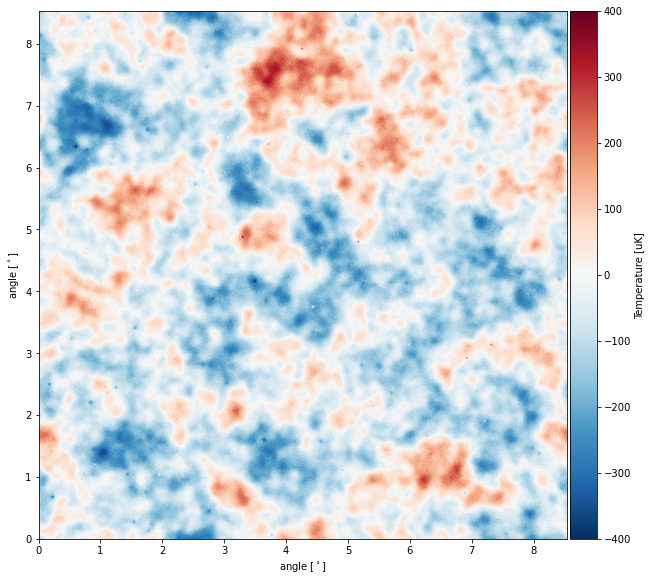

In [228]:
## Make a CMB map
ell, DlTT = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat", usecols=(0, 1), unpack=True) 
CMB_T = cmb_modules.make_CMB_T_map(N,pix_size,ell,DlTT)

## make a point source map
PSMap = cmb_modules.Poisson_source_component(N,pix_size,Number_of_Sources,Amplitude_of_Sources) 
PSMap +=  cmb_modules.Exponential_source_component(N,pix_size,Number_of_Sources_EX,Amplitude_of_Sources_EX)

## make an SZ map
SZMap,SZCat = cmb_modules.SZ_source_component(N,pix_size,Number_of_SZ_Clusters,Mean_Amplitude_of_SZ_Clusters,SZ_beta,SZ_Theta_core,False)

## add them all together to get the sky map at a single freuqency
total_map = CMB_T + PSMap + SZMap

## incorperate the impact of the instrument
    ## beam
CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,total_map)
    ## noise
Noise = cmb_modules.make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)

total_map_plus_noise = CMB_T_convolved + Noise

## plot the result
p=cmb_modules.Plot_CMB_Map(total_map_plus_noise,c_min,c_max,X_width,Y_width)

map mean: 1200.0196571350098 map rms: 716.1298930065927


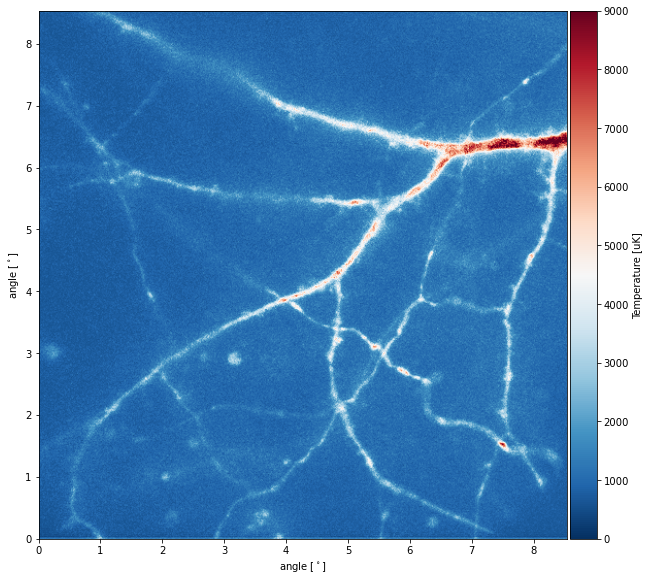

In [229]:
import h5py
filename = "calcium/19-2.tif"

import matplotlib.pyplot as plt
I = plt.imread(filename)
# plt.imshow(I)
# plt.colorbar()
# plt.show()

Ncalc = 512
X_widthcalc=512/60.
Y_widthcalc = 512/60.
c_maxcalc = 9000
c_mincalc = 0

p=cmb_modules.Plot_CMB_Map(I,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)

### Apodize  the map to eliminate edge effects

Before taking a 2d FFT (eg the obvious thing to do for computing a power spectrum) we must apodize the maps to eliminate edges effects.  Edge effects come about because the Fourier transform treats a square array as having periodic boundaries.  Thus if we take the Fourier transform of a 2-dimensional map and the values on the left and right side (and also, top and bottom) of the map don't match, we end up generating spurious signals.   In this example we use a cosine window to smoothly roll off the signal to zero as we approach the edges of the map.  There are many choices of windows that trade sensitivity loss, coupling of adjacent modes, and ringing.

map mean: -18.46316119767268 map rms: 52.12307298672875


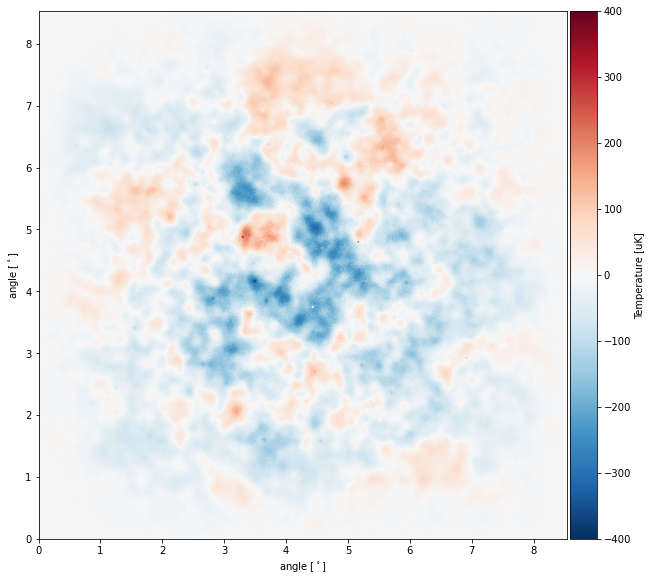

In [230]:
def cosine_window(N):
    "makes a cosine window for apodizing to avoid edges effects in the 2d FFT" 
    # make a 2d coordinate system
    N=int(N) 
    ones = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.)/N *np.pi ## eg runs from -pi/2 to pi/2
    X = np.outer(ones,inds)
    Y = np.transpose(X)
  
    # make a window map
    window_map = np.cos(X) * np.cos(Y)
   
    # return the window map
    return(window_map)
  ###############################
    
window = (cosine_window(N))
    
appodized_map = window * total_map_plus_noise


p=cmb_modules.Plot_CMB_Map(appodized_map,c_min,c_max,X_width,Y_width)

This shows our simulated map with a cosine window applied to eliminate edge effects.  It is obvious from this map that we are suppressing the signal here.
<font color='red'>EXERCISE: </font>  There are an huge number of well studied windows with various combinations of properties.   Some minimize mode coupling, others minimize signal loss, while others maximize some combination of the two.  Find the wikipedia article on Fourier transform windows, choose one of your favorites and implement it as an option.  Compare the impact of the new window compared to the simple cosine window on the map.

### Naive Powerspectrum

Here we compute a naive power spectrum and compare it to the input power spectrum for our simulations.  The power spectrum is computed by: (1) applying a 2d FFT, (2) taking the absolute value squared of this map in Fourier space ($k_x$ and $k_y$), and (3) averaging the signal in annular bins of $k = \sqrt{k_x^2 + k_y^2}$.  These bins are converted to bins in $\ell$ with the scaling: $\ell = k* 2 \pi$ per the flat sky approximation.   NOTE: step 3 (averaging in radial bins) is how we convert our 2d Fourier map into a 1d power spectrum.

Our spectrum code takes two maps as inputs to allow for cross spectra when we get to polarizaiton in Part Seven.

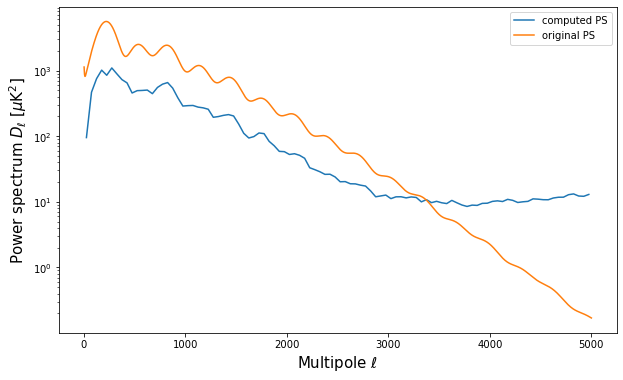

In [30]:
#### parameters for setting up the spectrum
delta_ell = 50.
ell_max = 5000.

if max(ell)< ell_max: 
        print('WARNING: Your theory curves end before the binned ell_max')

def calculate_2d_spectrum(Map1,Map2,delta_ell,ell_max,pix_size,N):
    "calcualtes the power spectrum of a 2d map by FFTing, squaring, and azimuthally averaging"
    N=int(N)
    # make a 2d ell coordinate system
    ones = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.) /(N-1.)
    kX = np.outer(ones,inds) / (pix_size/60. * np.pi/180.)
    kY = np.transpose(kX)
    K = np.sqrt(kX**2. + kY**2.)
    ell_scale_factor = 2. * np.pi 
    ell2d = K * ell_scale_factor
    
    # make an array to hold the power spectrum results
    N_bins = int(ell_max/delta_ell)
    ell_array = np.arange(N_bins)
    CL_array = np.zeros(N_bins)
    
    # get the 2d fourier transform of the map
    FMap1 = np.fft.ifft2(np.fft.fftshift(Map1))
    FMap2 = np.fft.ifft2(np.fft.fftshift(Map2))
    PSMap = np.fft.fftshift(np.real(np.conj(FMap1) * FMap2))
    # fill out the spectra
    i = 0
    while (i < N_bins):
        ell_array[i] = (i + 0.5) * delta_ell
        inds_in_bin = ((ell2d >= (i* delta_ell)) * (ell2d < ((i+1)* delta_ell))).nonzero()
        CL_array[i] = np.mean(PSMap[inds_in_bin])
        #print i, ell_array[i], inds_in_bin, CL_array[i]
        i = i + 1
 
    # return the power spectrum and ell bins
    return(ell_array,CL_array*np.sqrt(pix_size /60.* np.pi/180.)*2.)

plt.figure(figsize=(10,6))
## make a power spectrum
binned_ell, binned_spectrum = calculate_2d_spectrum(appodized_map,appodized_map,delta_ell,ell_max,pix_size,N)
#print binned_ell
plt.semilogy(binned_ell,binned_spectrum* binned_ell * (binned_ell+1.)/2. / np.pi, label='computed PS')
plt.semilogy(ell,DlTT, label='original PS')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

This plot shows the input CMB power spectrum and the naive power spectrum we estimated from our CMB map.  The naive spectrum does not match the input due to a combination of: instrumental noise, point source signals; and suppression from the beam and the apodization.   

<font color='red'>EXERCISE: </font>  Comment on how the measured power sepctrum compares to the input spectrum.  How (and why) are they different?  What features are common to both?  How does your alternative window funciton affect the measured spectrum compared to the default?

### Correcting the biases in the naive power spectrum

To correct the naive spectrum and obtain an unbiased estimate of the underlying power spectrum in our simulated map we must correct additive bias and multiplicative bias.   We can relate our measured spectrum $\hat D_\ell$ to the true underlying spectrum $D_\ell$ as follows:

$$\hat D_\ell = T*D_\ell + N. $$

Here $N$ represents an additive noise term and $T$ represents a transfer function of the instrument (beam) and filtering (in this case the apodization, but other processing can enter, for example a 1-d high pass filter to eliminate striping).   All of these terms are functions of $\ell$.

The true power spectrum can be recovered by using monte carlo technqies.  To apply this technique we use simulations to calibrate $T$ and $N$ and then use algebra to correct the naive measurement.  This is compactly expressed in the following equation:

$$ D_\ell = \hat (D_\ell - N)/T. $$

In the next two sections we use simulations to calibrate $T and $N$ to recover an unbiased estimate of the underlying power spectrum.  Subsequently we will used monte carlo simulations to estimate the error bars on this measurement.

### Calibrating the transfer function

The transfer function can be calibrated by: (1) generating sky simulations with a known power spectrum, modeling the transfer function of the instrument and the post-processing, and keeping the noise level to zero,; and (2) calculating the naive power spectrum from each simulation, (3) running many simulations to reduce numerical noise, and (4) dividing the true spectrum by the the average signal only spectrum to recover our estimate for the transfer function.   The accuracy depends on the number of realizations used.  Here  we used 64 realizations as a compromise between speed and accuracy.  

Here we use a CMB only spectrum to estimate the transfer function.  We could improve the estimate of the transfer function by using an input power spectrum that is modified to follow the effect of point sources.  This could be added as an exercise.  In this exercise compare the transfer function to find out how much the choice of input spectrum matters.

 signal only sims, iterations complete: 16 of 16

<Figure size 432x288 with 0 Axes>

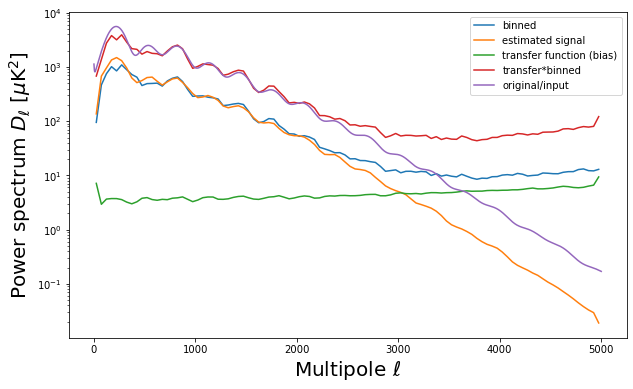

In [ ]:
N_iterations = 16

signal_only  = np.zeros([N_iterations,int(ell_max/delta_ell)])
i = 0
while (i <N_iterations):
    CMB_T = cmb_modules.make_CMB_T_map(N,pix_size,ell,DlTT)
    CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,CMB_T)
    binned_ell_cur, binned_spectrum_cur = calculate_2d_spectrum(CMB_T_convolved*window,CMB_T_convolved*window,delta_ell,ell_max,pix_size,N)
    signal_only[i,:] = binned_spectrum_cur
    sys.stdout.write("\r signal only sims, iterations complete: %d of %d" % ((i+1),N_iterations) )
    sys.stdout.flush()
    i = i + 1

def average_N_spectra(spectra,N_spectra,N_ells):
    avgSpectra = np.zeros(N_ells)
    rmsSpectra = np.zeros(N_ells)
    
    # calcuate the average spectrum
    i = 0
    while (i < N_spectra):
        avgSpectra = avgSpectra + spectra[i,:]
        i = i + 1
    avgSpectra = avgSpectra/(1. * N_spectra)
    
    #calculate the rms of the spectrum
    i =0
    while (i < N_spectra):
        rmsSpectra = rmsSpectra +  (spectra[i,:] - avgSpectra)**2
        i = i + 1
    rmsSpectra = np.sqrt(rmsSpectra/(1. * N_spectra))
    
    return(avgSpectra,rmsSpectra)


sig_only_mean_spectrum, rms_not_needed = average_N_spectra(signal_only,N_iterations,int(ell_max/delta_ell))
    
sub_sampled_CLs = DlTT[binned_ell] * 2. * np.pi / (binned_ell * (binned_ell+1.))

Multiplicative_Bias_est =  sub_sampled_CLs / sig_only_mean_spectrum
   
## make some plots
plt.clf()
plt.figure(figsize=(10,6))
plt.semilogy(binned_ell,binned_spectrum* binned_ell * (binned_ell+1.)/2. / np.pi,label='binned')
plt.semilogy(binned_ell,(sig_only_mean_spectrum)* binned_ell * (binned_ell+1.)/2. / np.pi,label='estimated signal')
plt.semilogy(binned_ell,(Multiplicative_Bias_est),label='transfer function (bias)')
plt.semilogy(binned_ell,(binned_spectrum)*Multiplicative_Bias_est* binned_ell * (binned_ell+1.)/2. / np.pi,label='transfer*binned')
plt.semilogy(ell,DlTT,label='original/input')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

This plot shows the estimate of the CMB power spectrum after correcting for the multiplicative bias (transfer function).   In addition we show the input CMB power spectrum, the average of the signal only simulations, the transfer function, and the naive power spectrum of our map.  Consider how all these curves relate to creating the estimate of the total signal.

<font color='red'>EXERCISE: </font>  Why does the estimated signal curve look like the red curve but surpressed?  What is the meaning of the lower transfer function curve? Also, what is happening on small scales (large $\ell$)?

### Calibrating the noise bias

The noise bias can be computed by running noise only simulations through the naive power spectrum estimator and computing the average power spectrum.

NOTE: An alternative approach exists for dealing with the noise.  If you can subdivide your data into subsets with common signal but independent noise, one can compute "cross-spectra" between these subsets.  (You compute these by doing a 2d FFT on each subset and then multiplying one by the complex conjugate of the other.)   This results in some information loss (since you are throwing out the auto-correlation of each subset), but it completely eliminates potential measurement bias from an incorrect noise model.  

As a two part exercise: (1) use the wrong noise model in analyzing the power spectrum to see what happens, and (2) implement a cross-spectrum estimator to see that this noise bias goes away with cross spectra.  Also note that the error bars grow with the cross spectrum. 

 noise only sims, iterations complete: 16 of 16

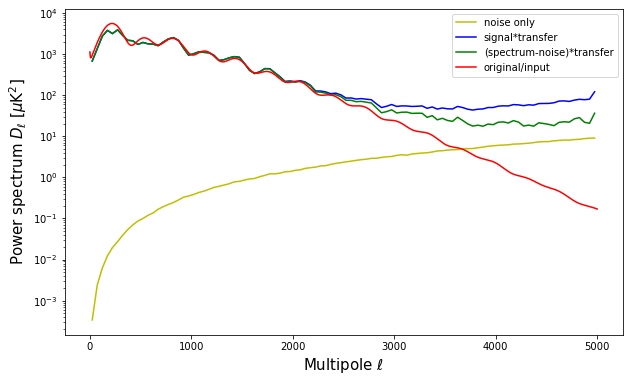

In [23]:
noise_only  = np.zeros([N_iterations,int(ell_max/delta_ell)])
i = 0
while (i <N_iterations):
    Noise = cmb_modules.make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)
    binned_ell_cur, binned_spectrum_cur = calculate_2d_spectrum(Noise*window,Noise*window,delta_ell,ell_max,pix_size,N)
    noise_only[i,:] = binned_spectrum_cur
    sys.stdout.write("\r noise only sims, iterations complete: %d of %d" % ((i+1),N_iterations) )
    sys.stdout.flush()
    i = i + 1

noise_only_mean_spectrum, rms_not_needed = average_N_spectra(noise_only,N_iterations,int(ell_max/delta_ell))

Additive_Bias_est = noise_only_mean_spectrum

plt.figure(figsize=(10,6))
plt.semilogy(binned_ell,(noise_only_mean_spectrum)* binned_ell * (binned_ell+1.)/2. / np.pi,color='y',label='noise only')
#plt.semilogy(binned_ell,(Multiplicative_Bias_est),color='b')
plt.semilogy(binned_ell,(binned_spectrum)*Multiplicative_Bias_est*\
             binned_ell * (binned_ell+1.)/2. / np.pi,color='b', label='signal*transfer')
plt.semilogy(binned_ell,(binned_spectrum -noise_only_mean_spectrum)\
             *Multiplicative_Bias_est* binned_ell * (binned_ell+1.)/2. / np.pi,color='g',label='(spectrum-noise)*transfer')
plt.semilogy(ell,DlTT,color='r', label='original/input')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

The green curve in this plot shows our unbiased estimate for the spectrum.  This estimate includes corrections for the noise bias and the transfer function.  The yellow curve shows our estimate for the noise only additive bias.  The blue curve shows the spectrum accounting for only the multiplicative bias as was done above.  The red curve shows the underlying power spectrum used in generating our simulated map.

At this point we have an unbiased estimate of the power spectrum (the green curve). Note that at high-$\ell$  the spectrum is dominated by the point source components.  Next we need to put error bars on this measurement.  Again we do this with the Monte Carlo approach.

### Quantifying the error bars

The error bars are computed by generating simulations including signal and noise, computing the naive power spectrum, taking the RMS of these results and then subtracting the noise bias and accounting for the transfer function.  In effect we are simulating running the experiment a bunch of times and looking at the RMS of the results--- this approach is broadly applicable to other problems.

Number of sources required:  5000
 signal and noise sims, iterations complete: 1 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 2 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 3 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 4 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 5 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 6 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 7 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 8 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 9 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 10 of 16Number of sources required:  5000
 signal and noise sims, iterations complete: 11 of 16Number of sources required:  5000
 signal and noise 

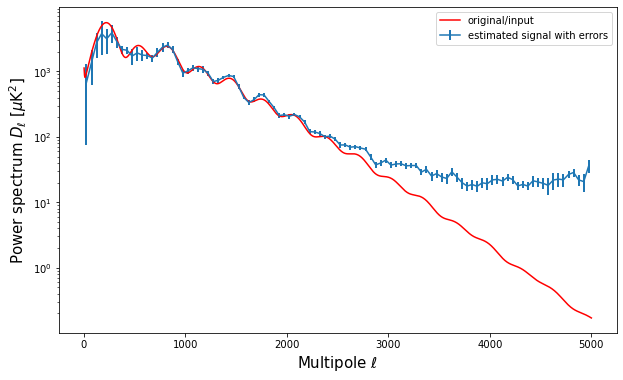

In [25]:
SplusN  = np.zeros([N_iterations,int(ell_max/delta_ell)])
i = 0
while (i <N_iterations):
    CMB_T = cmb_modules.make_CMB_T_map(N,pix_size,ell,DlTT)

    PSMap = cmb_modules.Poisson_source_component(N,pix_size,Number_of_Sources,Amplitude_of_Sources) 
    PSMap += cmb_modules.Exponential_source_component(N,pix_size,Number_of_Sources_EX,Amplitude_of_Sources_EX)
    SZMap,trash = cmb_modules.SZ_source_component(N,pix_size,Number_of_SZ_Clusters,\
                                      Mean_Amplitude_of_SZ_Clusters,SZ_beta,SZ_Theta_core,False)
    
    CMB_T  = CMB_T + PSMap + SZMap

    CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,CMB_T)
    Noise = cmb_modules.make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)
    binned_ell_cur, binned_spectrum_cur = calculate_2d_spectrum((CMB_T_convolved+Noise)*window\
                                                                ,(CMB_T_convolved+Noise)*window\
                                                                ,delta_ell,ell_max,pix_size,N)
    SplusN[i,:] = binned_spectrum_cur
    sys.stdout.write("\r signal and noise sims, iterations complete: %d of %d" % ((i+1),N_iterations) )
    sys.stdout.flush()
    #p=Plot_CMB_Map(CMB_T_convolved+Noise,c_min,c_max,X_width,Y_width)
    i = i + 1
    
mean_not_needed,rms_sig_plus_noise = average_N_spectra(SplusN,N_iterations,int(ell_max/delta_ell))


plt.clf()
plt.gcf().set_size_inches(10, 6)
plt.errorbar(binned_ell, (binned_spectrum -noise_only_mean_spectrum)*Multiplicative_Bias_est* \
             binned_ell * (binned_ell+1.)/2. / np.pi, \
             yerr=rms_sig_plus_noise*Multiplicative_Bias_est* binned_ell * (binned_ell+1.)/2. / np.pi,\
             elinewidth=2, label='estimated signal with errors')
plt.semilogy(ell,DlTT,color='r', label='original/input')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()




And there you have it.  That is how you compute a CMB power spectrum with error bars determined from the variance of a range of iterations. 

<font color='red'>EXERCISE: </font>  Why dosn't the red curve (input CMB spectrum) fall within the error bars of our simulated data set for values of the multipole above $\ell \sim 2500$? Is this based on our measurements or estimation procedure?

## Computing the power spectrum of the Calcium transient image

We now take apply the same power spectrum techniques to the Ca$^{2+}$ image, starting with the apodizatioon step.

map mean: 541.9189707027326 map rms: 575.2362584847183


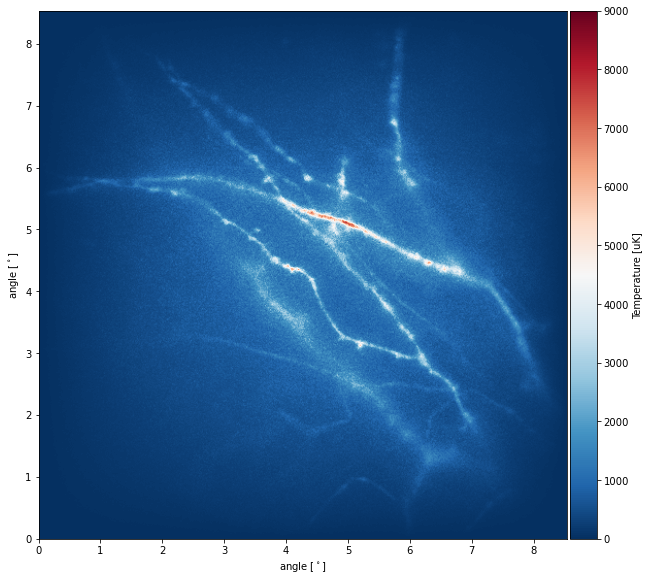

/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


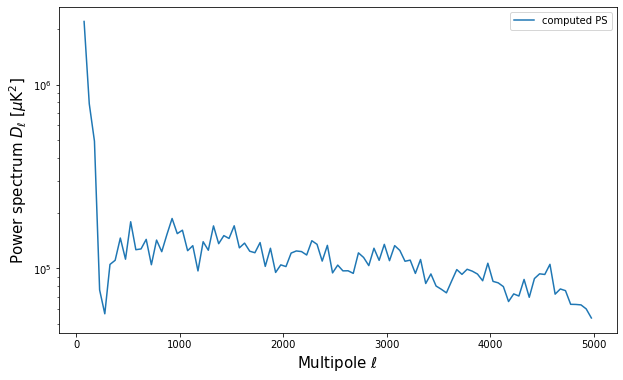

In [34]:
windowcalc = (cosine_window(Ncalc))
appodized_mapcalc = windowcalc * I
calcp=cmb_modules.Plot_CMB_Map(appodized_mapcalc,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)

plt.figure(figsize=(10,6))
#### parameters for setting up the spectrum
delta_ell = 50.
ell_max = 5000.

binned_ellcalc, binned_spectrumcalc = calculate_2d_spectrum(appodized_mapcalc,appodized_mapcalc,delta_ell,ell_max,pix_size,Ncalc)
#print binned_ell
plt.semilogy(binned_ellcalc,binned_spectrumcalc* binned_ellcalc * (binned_ellcalc+1.)/2. / np.pi, label='computed PS')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

Let's play around with changing the bin size to see if we are able to reconstructure some of the structure of this image.

/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


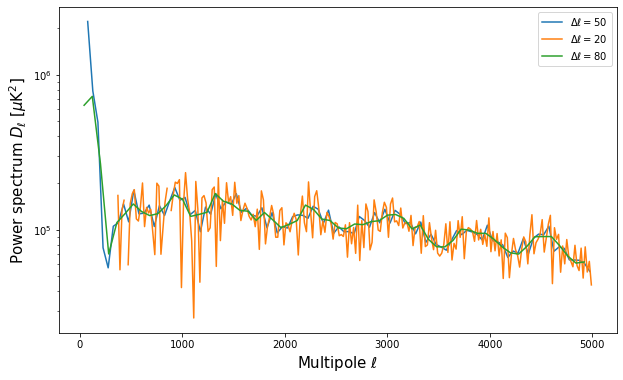

In [ ]:
plt.figure(figsize=(10,6))
#### parameters for setting up the spectrum
delta_ell=50.
delta_ellfine = 20.
ell_max = 5000.

delta_ellcourse = 80.
binned_ellcalcfine, binned_spectrumcalcfine = calculate_2d_spectrum(appodized_mapcalc,appodized_mapcalc,delta_ellfine,ell_max,pix_size,Ncalc)
binned_ellcalccourse, binned_spectrumcalccourse = calculate_2d_spectrum(appodized_mapcalc,appodized_mapcalc,delta_ellcourse,ell_max,pix_size,Ncalc)

#print binned_ell
plt.semilogy(binned_ellcalc,binned_spectrumcalc* binned_ellcalc * (binned_ellcalc+1.)/2. / np.pi, label='$\Delta \ell = 50$')
plt.semilogy(binned_ellcalcfine,binned_spectrumcalcfine* binned_ellcalcfine * (binned_ellcalcfine+1.)/2. / np.pi, label='$\Delta \ell = 20$')
plt.semilogy(binned_ellcalccourse,binned_spectrumcalccourse* binned_ellcalccourse * (binned_ellcalccourse+1.)/2. / np.pi, label='$\Delta \ell = 80$')

plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

<font color='red'>EXERCISE: </font>  How would this binning change depending on the PSF of your microscope?

## Noise estimation 

Let us use a part of the background to estimate the level of noise in the image.


map mean: 0.9809799194335938 map rms: 0.13659545051594385


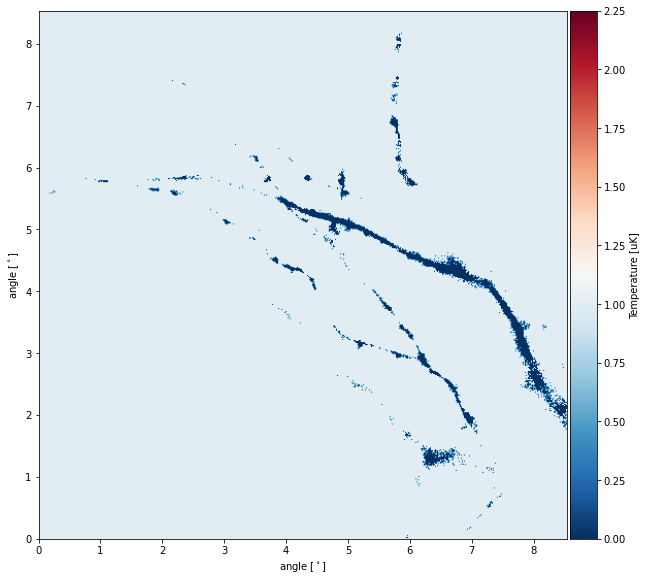

0.13659545051594385 noise std
636.9566406088103 total image std
map mean: -0.0015103313245625252 map rms: 0.6813714454508301


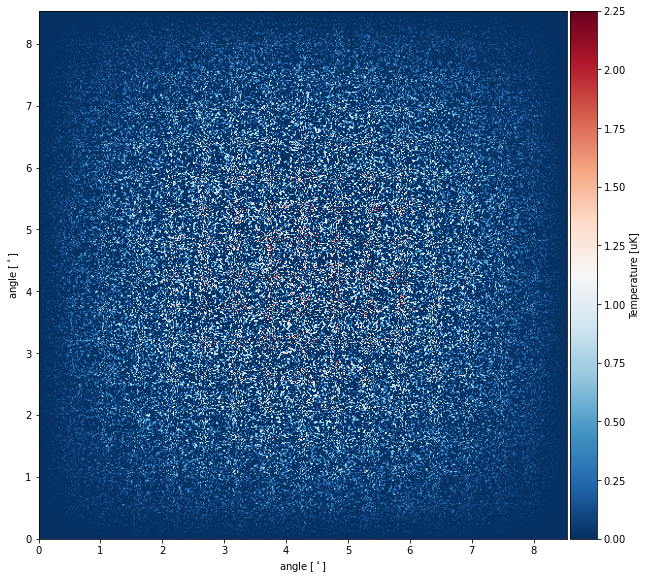

/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


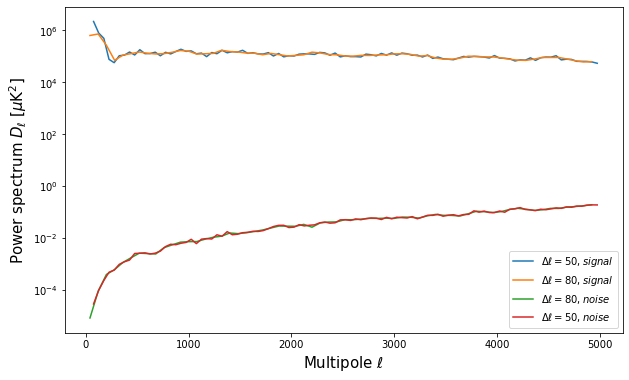

In [207]:
Inoise = I<5*np.std(I)
p=cmb_modules.Plot_CMB_Map(Inoise,c_mincalc/4000.,c_maxcalc/4000.,X_width,Y_width)

print(np.std(Inoise), 'noise std')
print(np.std(I), 'total image std')

white_noise_level = 5*np.std(Inoise)
atmospheric_noise_level = 0.0  # multiply by zero to turn this off
one_over_f_noise_level = 0.0# multiply by zero to turn this off

noise_calc=cmb_modules.make_noise_map(Ncalc,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)

N_mask =4
filteredI = cmb_modules.Filter_Map(noise_calc,Ncalc,N_mask)
appodized_noisecalc = windowcalc * noise_calc
p=cmb_modules.Plot_CMB_Map(appodized_noisecalc,c_mincalc/4000.,c_maxcalc/4000.,X_width,Y_width)


binned_ellnoisecalc, binned_spectrumnoisecalc = calculate_2d_spectrum(appodized_noisecalc,appodized_noisecalc,delta_ell,ell_max,pix_size,Ncalc)

binned_ellcalccourse, binned_spectrumcalccourse = calculate_2d_spectrum(appodized_mapcalc,appodized_mapcalc,delta_ellcourse,ell_max,pix_size,Ncalc)
binned_ellnoisecourse, binned_spectrumnoiseccourse = calculate_2d_spectrum(appodized_noisecalc,appodized_noisecalc,delta_ellcourse,ell_max,pix_size,Ncalc)

plt.figure(figsize=(10,6))
plt.semilogy(binned_ellcalc,binned_spectrumcalc* binned_ellcalc * (binned_ellcalc+1.)/2. / np.pi, label='$\Delta \ell = 50,signal$')
plt.semilogy(binned_ellcalccourse,binned_spectrumcalccourse* binned_ellcalccourse * (binned_ellcalccourse+1.)/2. / np.pi, label='$\Delta \ell = 80,signal$')
plt.semilogy(binned_ellnoisecourse,binned_spectrumnoiseccourse* binned_ellnoisecourse * (binned_ellnoisecourse+1.)/2. / np.pi, label='$\Delta \ell = 80, noise$')
plt.semilogy(binned_ellnoisecalc,binned_spectrumnoisecalc* binned_ellnoisecalc * (binned_ellnoisecalc+1.)/2. / np.pi, label='$\Delta \ell = 50, noise$')

plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

 noise only sims, iterations complete: 2 of 16

/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reneehlozek/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


 noise only sims, iterations complete: 16 of 16

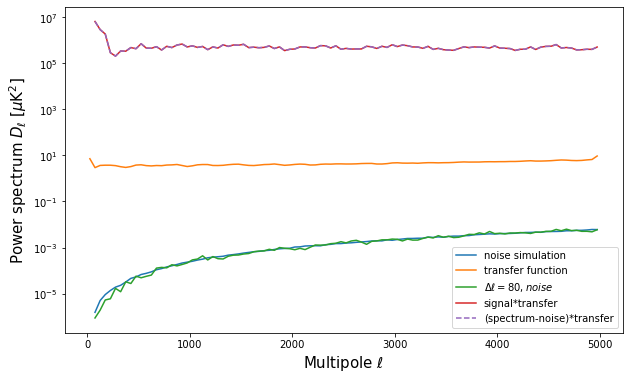

In [192]:
delta_ell = 50.
ell_max = 5000.

sig_only_mean_spectrum, rms_not_needed = average_N_spectra(signal_only,N_iterations,int(ell_max/delta_ell))
    
sub_sampled_CLs = DlTT[binned_ellcalc] * 2. * np.pi / (binned_ellcalc * (binned_ellcalc+1.))

Multiplicative_Bias_est =  sub_sampled_CLs / sig_only_mean_spectrum

noise_only  = np.zeros([N_iterations,int(ell_max/delta_ell)])
white_noise_level = 5*np.std(Inoise)
i = 0

binned_ellcalccourse, binned_spectrumcalccourse = calculate_2d_spectrum(appodized_mapcalc,appodized_mapcalc,delta_ellcourse,ell_max,pix_size,Ncalc)
N_iterations = 16

while (i <N_iterations):
    Noise = cmb_modules.make_noise_map(Ncalc,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)
    binned_ell_cur, binned_spectrum_cur = calculate_2d_spectrum(Noise*windowcalc ,Noise*windowcalc,delta_ell,ell_max,pix_size,Ncalc)
    noise_only[i,:] = binned_spectrum_cur
    sys.stdout.write("\r noise only sims, iterations complete: %d of %d" % ((i+1),N_iterations) )
    sys.stdout.flush()
    i = i + 1

noise_only_mean_spectrum, rms_not_needed = average_N_spectra(noise_only,N_iterations,int(ell_max/delta_ell))

Additive_Bias_est = noise_only_mean_spectrum

plt.figure(figsize=(10,6))
plt.semilogy(binned_ellcalc,(noise_only_mean_spectrum)* binned_ellcalc * (binned_ellcalc+1.)/(2.*np.pi),label='noise simulation')
plt.semilogy(binned_ellcalc,(Multiplicative_Bias_est),label='transfer function')
plt.semilogy(binned_ellnoisecalc,binned_spectrumnoisecalc* binned_ellnoisecalc * (binned_ellnoisecalc+1.)/(2. *np.pi), label='$\Delta \ell = 80, noise$')
plt.semilogy(binned_ellcalc,(binned_spectrumcalc)*Multiplicative_Bias_est*\
             binned_ellcalc * (binned_ellcalc+1.)/(2.*np.pi), label='signal*transfer')
plt.semilogy(binned_ellcalc,(binned_spectrumcalc -noise_only_mean_spectrum)\
             *Multiplicative_Bias_est* binned_ellcalc * (binned_ellcalc+1.)/(2.*np.pi),label='(spectrum-noise)*transfer',linestyle='--')
#plt.semilogy(ell,DlTT,color='r', label='original/input')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

## Generating a calcium image from the PS we computed

We can now use an estimate of the two power spectra to make an image. We need to have an $C_\ell$ value for each $\ell$ so we will need to spline the 

In [167]:
np.shape(binned_spectrumnoisecalc)
np.shape(binned_ellcalccourse)

(62,)

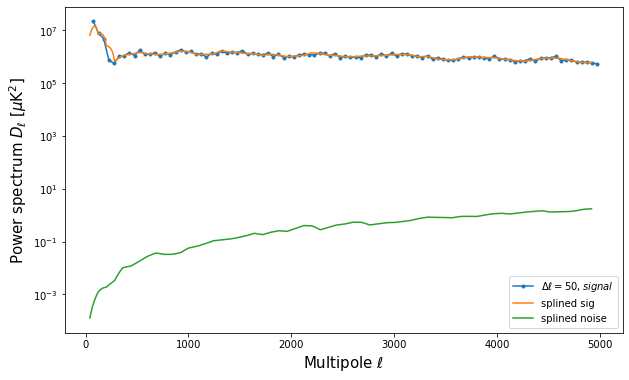

map mean: 904.822477013352 map rms: 2468.2006784351274


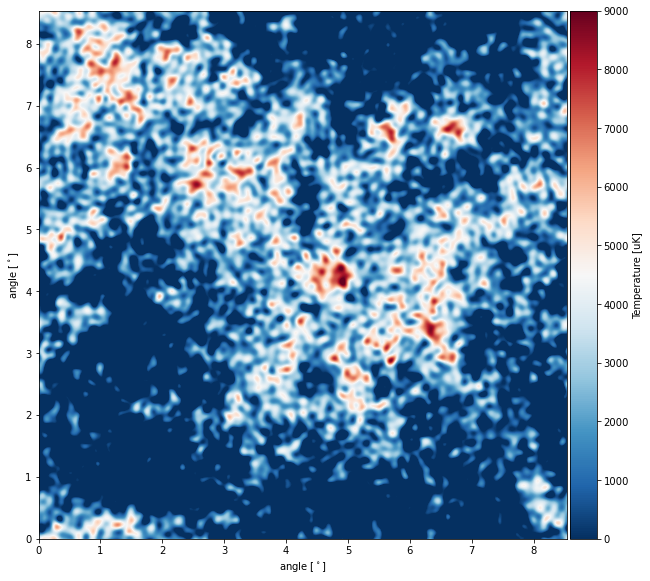

In [171]:
#plt.semilogy(binned_ellcalccourse,binned_spectrumcalccourse* binned_ellcalccourse * (binned_ellcalccourse+1.)/2. / np.pi, label='$\Delta \ell = 80,signal$')

import scipy.interpolate as interp

binned_calcsig = interp.interp1d(binned_ellcalccourse,binned_spectrumcalccourse)
binned_calcnoise = interp.interp1d(binned_ellcalccourse,binned_spectrumnoiseccourse)


dlspline = (binned_calcsig(ell[39:-80]))*ell[39:-80]*(ell[39:-80]+1)/(2./np.pi)

plt.figure(figsize=(10,6))

plt.semilogy(binned_ellcalc,binned_spectrumcalc*binned_ellcalc*(binned_ellcalc+1)/(2./np.pi), marker='.', label='$\Delta \ell = 50,signal$')

plt.semilogy(ell[39:-80],binned_calcsig(ell[39:-80])*ell[39:-80]*(ell[39:-80]+1)/(2./np.pi), label='splined sig')
plt.semilogy(ell[39:-80],binned_calcnoise(ell[39:-80])*ell[39:-80]*(ell[39:-80]+1)/(2./np.pi), label='splined noise')


#plt.semilogy(binned_ellcalc,binned_spectrumcalc* binned_ellcalc * (binned_ellcalc+1.)/2. / np.pi, label='$\Delta \ell = 50,signal$')
#plt.semilogy(binned_ellcalccourse,binned_spectrumcalccourse* binned_ellcalccourse * (binned_ellcalccourse+1.)/2. / np.pi, label='$\Delta \ell = 80,signal$')
# #plt.semilogy(binned_ellnoisecourse,binned_spectrumnoiseccourse* binned_ellnoisecourse * (binned_ellnoisecourse+1.)/2. / np.pi, label='$\Delta \ell = 80, noise$')
# #plt.semilogy(binned_ellnoisecalc,binned_spectrumnoisecalc* binned_ellnoisecalc * (binned_ellnoisecalc+1.)/2. / np.pi, label='$\Delta \ell = 50, noise$')
# plt.semilogy(ell[39:-80],binnedvals(ell[39:-80]), label='splined')
plt.legend()
plt.ylabel('Power spectrum $D_{\ell}$ [$\mu$K$^2$]', fontsize=15)
plt.xlabel('Multipole $\ell$',fontsize=15)
plt.show()

genI= cmb_modules.make_CMB_T_map(Ncalc,pix_size,ell[39:-80],dlspline)
# plt.imshow(test)
calcp=cmb_modules.Plot_CMB_Map(genI,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)

<font color='red'>EXERCISE: </font>  Note that this does not look like our original? What is the difference between this application and our CMB maps? [Hint: the power spectrum (unlike the Fourier Transform) does not preserve phase information]



## Matched filtering techniques

We will apply matched filtering to try and isolate some transients in these maps and images. We construct a single frequency matched filter following Melin et al. 2006. We build the following filter in Fourier space:

$$\psi = \frac{B_\ell S_\ell }{B_\ell^2 N^2_{ap,\ell} +N^2_{ins,\ell} } $$

Both $\psi$ and all the other quantities are two dimensional in the sense that they depend on $k_x$ and $k_y$. We refer to these coordinates with a $\ell$ as shorthand. In this equation, $B_\ell$ is the Fourier transform of the beam pattern and filtering; $S_\ell$ is the Fourier transform of the signal template; $N^2_{ap,\ell}$ is the power spectrum (e.g., absolute value squared of the 2d FFT) of the astrophysical noise from sources other than what is desired to be found, and $N^2_{ins,\ell}$ is the power spectrum of the instrumental response.


In the next box we define a function to calculate the matched filter and a function to plot the resulting map. In subsequent boxes we do the work of estimating the terms in the filter. 


In [195]:
def matched_filter(input_map, beam_and_filt, signal_profile, FT_noise_covar):
    ## input_map: the map we are processing
    ## beam_and_filt: the beam convolved with any map filtering, in real space
    ## signal_profile: the shape of the signal we are looking for, in real spcae
    ## FT_noise_covar: the B_N_{ap}^2 + N_{ins}^2 in Fourier space
    ## calculating FT_npoise_covar is expensive so it is done externally

    FT_beam_and_filt = np.fft.fft2(
        np.fft.fftshift(beam_and_filt)
    )  ## transform beam_and_filt to Fourier space
    FT_signal = np.fft.fft2(
        np.fft.fftshift(signal_profile)
    )  ## transform cluster_profile to Fourier space

    psi = (
        FT_beam_and_filt * FT_signal / FT_noise_covar
    )  ## define the matchedfilter function

    filtered = psi * np.fft.fft2(np.fft.fftshift(input_map))  ## filter the map
    filtered = np.fft.fftshift(np.fft.ifft2(filtered))  ## center the filter
    filtered = np.real(filtered)  ## change the data type to real
    return filtered


def Plot_Matched_Filtered_Map(Map_to_Plot, X_width, Y_width):
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    print("map mean:", np.mean(Map_to_Plot), "map rms:", np.std(Map_to_Plot))
    plt.figure(figsize=[10, 10])
    im = plt.imshow(
        Map_to_Plot, interpolation="bilinear", origin="lower", cmap=cm.RdBu_r
    )
    # im.set_clim(c_min,c_max)
    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    im.set_extent([0, X_width, 0, Y_width])
    plt.ylabel(r"angle $[^\circ]$")
    plt.xlabel(r"angle $[^\circ]$")
    cbar.set_label(r"matched_filter [S/N]", rotation=270)
    plt.show()
    return 0

The first thing we need is the noise covariance, which we do from multiple simulations of the maps. 

In [196]:
## construct the 2d noise covariance in Fourier space
FT_noise_covar = np.zeros((N, N))  ## a 2d array to hold the result

N_iterations = 16

## make a series of simulated maps, find the power spectrum, and average these to estimate the noise covariance
i = 0
while i < N_iterations:
    ## simulate the astrophysical map
    CMB_T = cmb_modules.make_CMB_T_map(N, pix_size, ell, DlTT)
    PSMap = cmb_modules.Poisson_source_component(
        N, pix_size, Number_of_Sources, Amplitude_of_Sources
    )
    PSMap += cmb_modules.Exponential_source_component(
        N, pix_size, Number_of_Sources_EX, Amplitude_of_Sources_EX
    )
    SZMap, trash = cmb_modules.SZ_source_component(
        N,
        pix_size,
        Number_of_SZ_Clusters,
        Mean_Amplitude_of_SZ_Clusters,
        SZ_beta,
        SZ_Theta_core,
        False,
    )
    CMB_T = CMB_T + PSMap + SZMap  ## the astrophysical map

    ## fold in the instrument response
    CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(
        N, pix_size, beam_size_fwhp, CMB_T
    )
    Noise = cmb_modules.make_noise_map(
        N, pix_size, white_noise_level, atmospheric_noise_level, one_over_f_noise_level
    )

    ## Fourier transform the map
    temp = np.fft.fft2(
        np.fft.fftshift(window * (CMB_T_convolved + Noise))
    )  ## these are the two terms in the denominator

    ## now average
    FT_noise_covar += np.real(np.conj(temp) * temp / (N_iterations * 1.0))
    ## note the progress
    sys.stdout.write(
        "\r matched filter noise realization, iterations complete: {} of {}".format(
            (i + 1), N_iterations
        )
    )
    sys.stdout.flush()
    ## iterate
    i = i + 1

Number of sources required:  5000
 matched filter noise realization, iterations complete: 1 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 2 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 3 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 4 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 5 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 6 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 7 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 8 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 9 of 16Number of sources required:  5000
 matched filter noise realization, iterations complete: 10 of 16Number of sources required:  

Now that we have the noise covariance and a function to compute the matched filter, we filter our map. To interpret this map we will divide by the standard deviation of the filtered map to put our map in signal to noise units.   

You can play around with the number of iterations you use in the Monte Carlo of the noise term. If it is too small, you will get high frequency ringing.

map mean: -52.17010834494795 map rms: 93.74534146647633


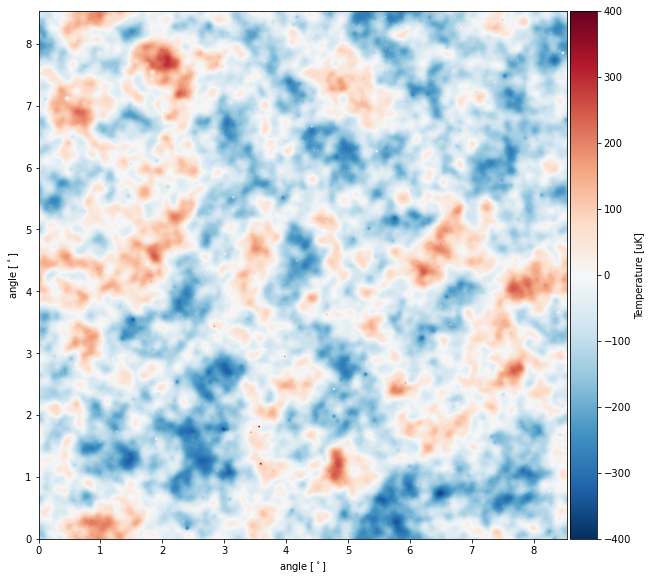

map mean: -0.0006945118305305134 map rms: 1.0


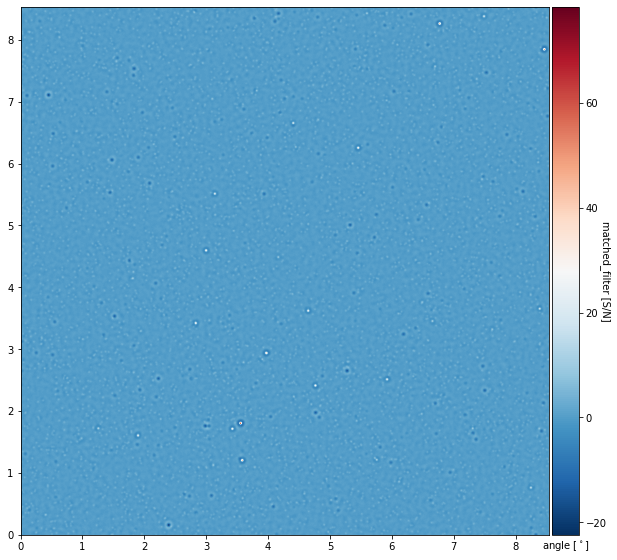

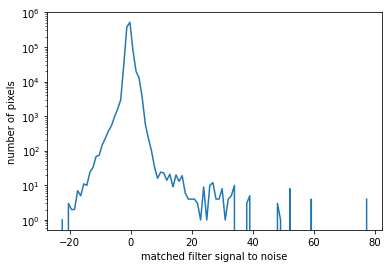

In [199]:
## construct the beam and cluster profile for the numerator of the matched filter
beam_and_filt = cmb_modules.make_2d_gaussian_beam(
    N, pix_size, beam_size_fwhp
)  ## this is the filtering we did on the map
cluster_profile = cmb_modules.beta_function(
    N, pix_size, SZ_beta, SZ_Theta_core
)  ## this is the signal we are looking for

## Apply the matched filter to our map
filtered_map = matched_filter(
    total_map_plus_noise, beam_and_filt, cluster_profile, FT_noise_covar
)

## make a S/N map
SN_map = filtered_map / np.std(filtered_map)

## make a few plots
p = cmb_modules.Plot_CMB_Map(total_map_plus_noise, c_min, c_max, X_width, Y_width)
p = Plot_Matched_Filtered_Map(SN_map, X_width, Y_width)

cluster_hist, cluster_bin_edges = np.histogram(
    SN_map, bins=100, range=[SN_map.min(), SN_map.max()]
)
plt.semilogy(cluster_bin_edges[0:-1], cluster_hist)
plt.ylabel("number of pixels")
plt.xlabel("matched filter signal to noise")
plt.show()

Here we show three maps: (top) the raw simulated map, (middle) the matched filtered map, and (bottom) a histogram of the S/N of each pixel in the matched filter map. You could identify sources by doing a S/N cut and taking all the pixels below say -5. To find point sources we would replace the $\beta$ function in the definition of the filter with a $\delta$ function and repeat the exercise looking for S/N greater than say 5.

NOTE: The signal to noise cut at $5 \sigma$ is not sacred. It is chosen so that the probability of a spurious cluster (or point source) detection is controlled to be irrelevant on a ~100 degree patch with arcminute resolution. Depending on the application, this cut should be adjusted.

## Applying the matched filter to our Calcium transient images



In [222]:
print(beam_size_fwhp)

1.25


In [225]:
## construct the 2d noise covariance in Fourier space
FT_noise_covarc = np.zeros((Ncalc, Ncalc))  ## a 2d array to hold the result

beam_size_fwhpc = 3.
N_iterations = 16

## make a series of simulated maps, find the power spectrum, and average these to estimate the noise covariance
i = 0
while i < N_iterations:
    ## simulate the astrophysical map
    CalcT= cmb_modules.make_CMB_T_map(Ncalc,pix_size,ell[39:-80],dlspline)


    ## fold in the instrument response
    CalcT_convolved = cmb_modules.convolve_map_with_gaussian_beam(
        Ncalc, pix_size, beam_size_fwhp, CMB_T
    )
    Noisec = cmb_modules.make_noise_map(
        Ncalc, pix_size, white_noise_level, atmospheric_noise_level, one_over_f_noise_level
    )

    ## Fourier transform the map
    temp = np.fft.fft2(
        np.fft.fftshift(windowcalc * (CalcT_convolved + Noisec))
    )  ## these are the two terms in the denominator

    ## now average
    FT_noise_covarc += np.real(np.conj(temp) * temp / (N_iterations * 1.0))
    ## note the progress
    sys.stdout.write(
        "\r matched filter noise realization, iterations complete: {} of {}".format(
            (i + 1), N_iterations
        )
    )
    sys.stdout.flush()
    ## iterate
    i = i + 1

 matched filter noise realization, iterations complete: 16 of 16

map mean: 1215.0998420715332 map rms: 636.9566406088103


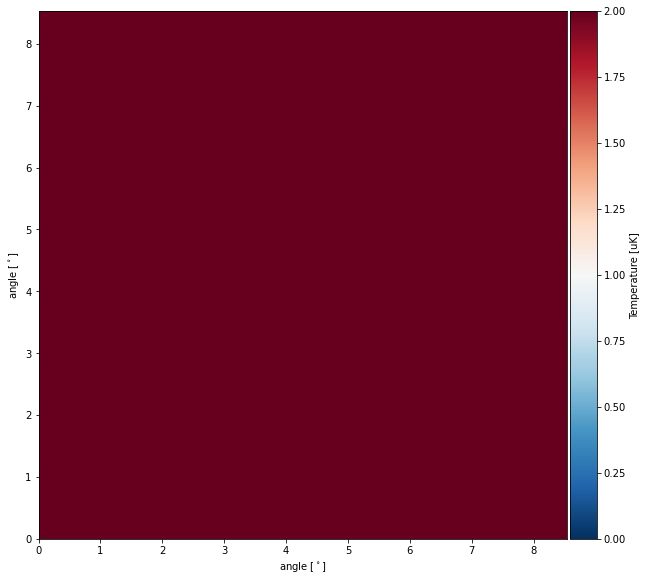

map mean: 3.530819053060897e-06 map rms: 1.0


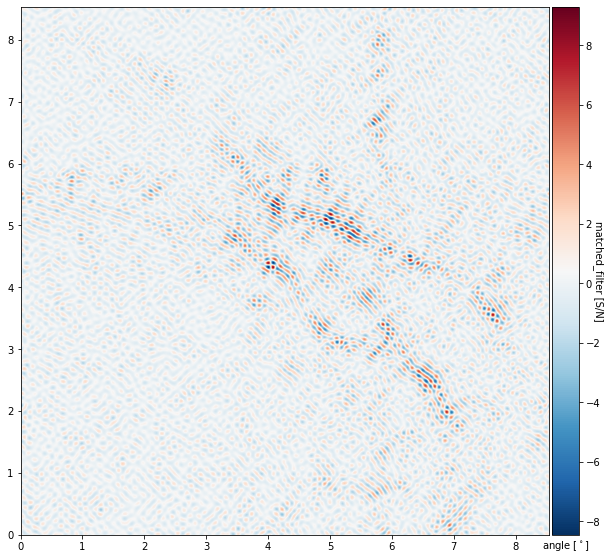

In [226]:
## construct the beam and cluster profile for the numerator of the matched filter
beam_and_filt = cmb_modules.make_2d_gaussian_beam(
    Ncalc, pix_size, beam_size_fwhpc
)  ## this is the filtering we did on the map

cluster_profile = cmb_modules.beta_function(
    Ncalc, pix_size, SZ_beta, SZ_Theta_core
)  ## this is the signal we are looking for

## Apply the matched filter to our map
filtered_map = matched_filter(
    I, beam_and_filt, cluster_profile, FT_noise_covarc
)

## make a S/N map
SN_map = filtered_map / np.std(filtered_map)
## make a few plots
p = cmb_modules.Plot_CMB_Map(I, 0,2, X_width, Y_width)
p = Plot_Matched_Filtered_Map(SN_map, X_width, Y_width)
